In [ ]:
### To install matplotlib here run the following (once and for all)
# using CondaPkg
# CondaPkg.add("matplotlib")

## This cell needs to be run before calling Julia's Plots package.

using PythonCall
pyimport("matplotlib.pyplot")

Python: <module 'matplotlib.pyplot' from '/home/archisman/.julia/environments/v1.12/.CondaPkg/.pixi/envs/default/lib/python3.14/site-packages/matplotlib/pyplot.py'>

In [24]:

data_dir_stats = joinpath(@__DIR__, "bott_index_data")

function parse_params_stats(filename)
    m = match(r"_m_0=([0-9.eE+-]+)_.*_L=(\d+)_proportion_sites=([0-9.eE+-]+)_", filename)
    m === nothing && return nothing
    return (m_0=parse(Float64, m.captures[1]), L=parse(Int, m.captures[2]), proportion_sites=parse(Float64, m.captures[3]))
end

all_files = filter(f -> endswith(f, ".csv"), readdir(data_dir_stats))
params_list = filter(!isnothing, parse_params_stats.(all_files))

target = -1.75
filtered = filter(p -> isapprox(p.m_0, target; atol=1e-12, rtol=0), params_list)

counts = Dict{Tuple{Int,Float64}, Int}()
for p in filtered
    key = (p.L, p.proportion_sites)
    counts[key] = get(counts, key, 0) + 1
end

all_L = sort(unique(first.(keys(counts))))

println("m_0 = $target  —  available data (one CSV = one data point)\n")
println("$(lpad("L", 6))  $(lpad("proportion_sites", 18))  $(lpad("n_files", 8))")
println(repeat("-", 38))
for L in all_L
    props = sort(unique([k[2] for k in keys(counts) if k[1] == L]))
    for p in props
        n = counts[(L, p)]
        println("$(lpad(L, 6))  $(lpad(p, 18))  $(lpad(n, 8))")
    end
    println()
end

m_0 = -1.75  —  available data (one CSV = one data point)

     L    proportion_sites   n_files
--------------------------------------
    88               0.087       800
    88               0.088       400
    88              0.0885       200
    88               0.089       800
    88              0.0895       797
    88              0.0898       800
    88                0.09       800
    88              0.0903       800
    88              0.0905       800
    88               0.091       797
    88              0.0915       200
    88               0.092       399
    88               0.093       794

   100               0.087       200
   100               0.088       400
   100              0.0885       200
   100               0.089       200
   100              0.0893       800
   100              0.0895       800
   100              0.0897       800
   100              0.0898       799
   100                0.09       800
   100              0.0901       800
   100       

# Bott Index Histogram

Analyze the distribution of `bott_index` values across all CSV runs with a selected `L` and `proportion_sites`.

In [25]:
using CSV, DataFrames, Dates, Statistics, StatsBase, Plots, LaTeXStrings

# Shared publication-quality styling for every plot in this notebook.
default(;
    size=(900, 600),
    dpi=300,
    fontfamily="Computer Modern",
    framestyle=:box,
    foreground_color_border=:black,
    foreground_color_axis=:black,
    foreground_color_text=:black,
    linewidth=2.2,
    markersize=7,
    markerstrokewidth=1.2,
    tickfontsize=26,
    guidefontsize=32,
    titlefontsize=22,
    legendfontsize=24,
    colorbar_tickfontsize=28,
    colorbar_titlefontsize=21,
    formatter=:latex,
    colorbar_formatter=:latex,
    gridalpha=0.18,
    minorgridalpha=0.08,
    background_color=:white,
)

# PDF exports are written relative to the repository root.
plot_output_dir = normpath(joinpath(@__DIR__, "..", "..", "..", "data plots", "chern_BHZ", "bott_index"))
mkpath(plot_output_dir)
plot_pdf_path(stem, m_0=target) = joinpath(plot_output_dir, "$(stem)_m_0=$(m_0).pdf")

plot_pdf_path (generic function with 2 methods)

In [26]:
function _parse_bott_filename(filename)
    m = match(r"_m_0=([0-9.eE+-]+)_.*_L=(\d+)_proportion_sites=([0-9.eE+-]+)_.*_(\d{4}-\d{2}-\d{2}_\d{6})\.csv$", filename)
    m === nothing && return nothing
    (m_0=parse(Float64, m.captures[1]), L=parse(Int, m.captures[2]),
     proportion_sites=parse(Float64, m.captures[3]),
     timestamp=DateTime(m.captures[4], dateformat"yyyy-mm-dd_HHMMSS"))
end

function bott_histogram(target_L, target_proportion_sites, target_m_0; data_dir=data_dir_stats, n_max=typemax(Int), report_counts=true)
    all_files = filter(f -> endswith(f, ".csv"), readdir(data_dir))
    matching = filter(all_files) do f
        p = _parse_bott_filename(f)
        p === nothing && return false
        isapprox(p.m_0, target_m_0; atol=1e-12, rtol=0) &&
        p.L == target_L &&
        isapprox(p.proportion_sites, target_proportion_sites; atol=1e-12, rtol=0)
    end
    sort!(matching; by=f -> _parse_bott_filename(f).timestamp)
    isempty(matching) && error("No files for m_0=$target_m_0, L=$target_L, proportion_sites=$target_proportion_sites")

    n_available = length(matching)
    matching = matching[1:min(n_max, n_available)]

    bott_values = map(matching) do f
        path = joinpath(data_dir, f)
        df = CSV.read(path, DataFrame; silencewarnings=true)
        if !hasproperty(df, :bott_index)
            return missing
        end

        vals = collect(skipmissing(df.bott_index))
        isempty(vals) && return missing
        round(Int, vals[end])
    end
    bott_values = filter(!ismissing, bott_values)
    n_averaged = length(bott_values)

    if report_counts
        coverage_pct = round(100 * n_averaged / n_available; digits=1)
        limited = n_averaged < n_available ? " (limited by n_max=$n_max)" : ""
        println("m_0=$target_m_0, L=$target_L, x=$target_proportion_sites: averaged $n_averaged / $n_available available values ($coverage_pct%)$limited")
    end

    mode_val = StatsBase.mode(bott_values)
    mean_val = mean(bott_values)

    p = histogram(bott_values;
        bins=collect(-5.5:1.0:5.5),
        titlefontsize=22,
        normalize=:probability,
        xlabel=L"\mathrm{Bott\ index}",
        ylabel=L"\mathrm{Probability}",
        title=latexstring("m_0 = ", target_m_0, raw",\quad L = ", target_L, raw",\quad x = ", target_proportion_sites, raw",\quad (n = ", length(bott_values), ")"),
        label=L"\mathrm{Bott\ index}",
        alpha=0.75,
        xlim=(-5.5, 5.5),
        xticks=-5:5,
    )
    vline!(p, [mode_val]; label=latexstring(raw"\mathrm{mode} = ", mode_val), linewidth=2.4, color=:red)
    vline!(p, [mean_val]; label=latexstring(raw"\mathrm{mean} = ", round(mean_val, digits=3)), linewidth=2.4, color=:blue, linestyle=:dash)
    return p, mean_val
end

bott_histogram (generic function with 1 method)

In [27]:
if target == -1.75
    x_vals = [0.087,0.088, 0.0885, 0.089, 0.0893, 0.0895, 0.0897,0.0898, 0.09,0.0901,0.0903, 0.0905,0.091,0.0915,0.092,0.093] ### For -1.75
elseif target == -1.5
    x_vals = [0.1625,0.163,0.165,0.166, 0.1665,0.1668, 0.167, 0.1672, 0.1675, 0.1678, 0.168, 0.1682,0.1685, 0.1688,0.169,0.17,0.171,0.1725] ## pm 1.5
elseif target == 1.0 || target == -1.0
    x_vals = [0.265,0.268,0.271,0.275,0.278,0.281,0.284,0.285,0.286,0.287,0.288,0.2885,0.290,0.291,0.292,0.294,0.297,0.3,0.304,0.307,0.31] #pm 1
elseif target == -1.25
    x_vals = x_vals = [0.227,0.228,0.229,0.23,0.2305,0.231,0.2315,0.232,0.2325,0.233,0.2335,0.234,0.2345,0.235,0.2355,0.236,0.2365,0.237,0.238,0.239,0.24] ### For -1.25
elseif target == -0.75
    x_vals = [0.26,0.265,0.27,0.275,0.28,0.285,0.29,0.295] ### For -0.75
elseif target == 0.75
    x_vals = [0.26,0.265,0.27,0.275,0.28,0.285,0.29,0.295,0.3,0.305,0.31,0.315] ### For 0.75
elseif target == -0.5
    x_vals = [0.26,0.265,0.27,0.275,0.28,0.285,0.29,0.295] ### For -0.5
elseif target == -0.25
    x_vals = [0.23,0.235,0.24,0.245,0.25,0.255] ### For -0.25
elseif target == -0.2
    x_vals = [0.23,0.235,0.24,0.245,0.25,0.255,0.26,0.265,0.27] ### For -0.2
elseif target == -0.15
    x_vals = [0.23,0.235,0.24,0.245,0.25,0.255,0.26,0.265,0.27] ### For -0.15
elseif target == -0.1
    x_vals = [0.23,0.235,0.24,0.245,0.25,0.255,0.26,0.265,0.27] ### For -0.1
elseif target == -0.05
    x_vals = [0.23,0.235,0.24,0.245,0.25,0.255,0.26,0.265,0.27] ### For -0.05
end
max_num_to_try = 1300;

L88_vals = Float64[]
L100_vals = Float64[]
L_120_vals = Float64[]
L_132_vals = Float64[]

# Returns mean bott index, or NaN if data/file does not exist (or any read/parse error happens).
safe_mean(L, x) = try
    _, mean_val = bott_histogram(L, x, target; n_max=max_num_to_try)
    mean_val
catch err
    @warn "Mean calculation failed" L x exception=(err, catch_backtrace())
    NaN
end

for x in x_vals
    push!(L88_vals, safe_mean(88, x))
    push!(L100_vals, safe_mean(100, x))
    push!(L_120_vals, safe_mean(120, x))
    push!(L_132_vals, safe_mean(132, x))
end

# Keep only finite y values (and their corresponding x values)
finite_xy(x, y) = begin
    idx = isfinite.(y)
    x[idx], y[idx]
end

x88,  y88  = finite_xy(x_vals, L88_vals)
x100, y100 = finite_xy(x_vals, L100_vals)
x120, y120 = finite_xy(x_vals, L_120_vals)
x132, y132 = finite_xy(x_vals, L_132_vals)

m_0=-1.75, L=88, x=0.087: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=100, x=0.087: averaged 200 / 200 available values (100.0%)
m_0=-1.75, L=120, x=0.087: averaged 200 / 200 available values (100.0%)
m_0=-1.75, L=132, x=0.087: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=88, x=0.088: averaged 400 / 400 available values (100.0%)
m_0=-1.75, L=100, x=0.088: averaged 400 / 400 available values (100.0%)
m_0=-1.75, L=120, x=0.088: averaged 400 / 400 available values (100.0%)
m_0=-1.75, L=132, x=0.088: averaged 400 / 400 available values (100.0%)
m_0=-1.75, L=88, x=0.0885: averaged 200 / 200 available values (100.0%)
m_0=-1.75, L=100, x=0.0885: averaged 200 / 200 available values (100.0%)
m_0=-1.75, L=120, x=0.0885: averaged 200 / 200 available values (100.0%)
m_0=-1.75, L=132, x=0.0885: averaged 200 / 200 available values (100.0%)
m_0=-1.75, L=88, x=0.089: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=100, x=0.089: averaged 200 / 200 available values (

┌ Warning: Mean calculation failed
│   L = 88
│   x = 0.0893
│   exception =
│    No files for m_0=-1.75, L=88, proportion_sites=0.0893
│    Stacktrace:
│     [1] error(s::String)
│       @ Base ./error.jl:44
│     [2] bott_histogram(target_L::Int64, target_proportion_sites::Float64, target_m_0::Float64; data_dir::String, n_max::Int64, report_counts::Bool)
│       @ Main ./In[26]:19
│     [3] safe_mean(L::Int64, x::Float64)
│       @ Main ./In[27]:35
│     [4] top-level scope
│       @ ./In[27]:43
│     [5] eval(m::Module, e::Any)
│       @ Core ./boot.jl:489
│     [6] include_string(mapexpr::typeof(REPL.softscope), mod::Module, code::String, filename::String)
│       @ Base ./loading.jl:2874
│     [7] execute_request(socket::ZMQ.Socket, kernel::IJulia.Kernel, msg::IJulia.Msg)
│       @ IJulia ~/.julia/packages/IJulia/Vl5w1/src/execute_request.jl:129
│     [8] eventloop(socket::ZMQ.Socket, kernel::IJulia.Kernel)
│       @ IJulia ~/.julia/packages/IJulia/Vl5w1/src/eventloop.jl:26
│     

m_0=-1.75, L=100, x=0.0893: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=120, x=0.0893: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=132, x=0.0893: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=88, x=0.0895: averaged 797 / 797 available values (100.0%)
m_0=-1.75, L=100, x=0.0895: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=120, x=0.0895: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=132, x=0.0895: averaged 800 / 800 available values (100.0%)


┌ Warning: Mean calculation failed
│   L = 88
│   x = 0.0897
│   exception =
│    No files for m_0=-1.75, L=88, proportion_sites=0.0897
│    Stacktrace:
│     [1] error(s::String)
│       @ Base ./error.jl:44
│     [2] bott_histogram(target_L::Int64, target_proportion_sites::Float64, target_m_0::Float64; data_dir::String, n_max::Int64, report_counts::Bool)
│       @ Main ./In[26]:19
│     [3] safe_mean(L::Int64, x::Float64)
│       @ Main ./In[27]:35
│     [4] top-level scope
│       @ ./In[27]:43
│     [5] eval(m::Module, e::Any)
│       @ Core ./boot.jl:489
│     [6] include_string(mapexpr::typeof(REPL.softscope), mod::Module, code::String, filename::String)
│       @ Base ./loading.jl:2874
│     [7] execute_request(socket::ZMQ.Socket, kernel::IJulia.Kernel, msg::IJulia.Msg)
│       @ IJulia ~/.julia/packages/IJulia/Vl5w1/src/execute_request.jl:129
│     [8] eventloop(socket::ZMQ.Socket, kernel::IJulia.Kernel)
│       @ IJulia ~/.julia/packages/IJulia/Vl5w1/src/eventloop.jl:26
│     

m_0=-1.75, L=100, x=0.0897: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=120, x=0.0897: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=132, x=0.0897: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=88, x=0.0898: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=100, x=0.0898: averaged 799 / 799 available values (100.0%)
m_0=-1.75, L=120, x=0.0898: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=132, x=0.0898: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=88, x=0.09: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=100, x=0.09: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=120, x=0.09: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=132, x=0.09: averaged 800 / 800 available values (100.0%)


┌ Warning: Mean calculation failed
│   L = 88
│   x = 0.0901
│   exception =
│    No files for m_0=-1.75, L=88, proportion_sites=0.0901
│    Stacktrace:
│     [1] error(s::String)
│       @ Base ./error.jl:44
│     [2] bott_histogram(target_L::Int64, target_proportion_sites::Float64, target_m_0::Float64; data_dir::String, n_max::Int64, report_counts::Bool)
│       @ Main ./In[26]:19
│     [3] safe_mean(L::Int64, x::Float64)
│       @ Main ./In[27]:35
│     [4] top-level scope
│       @ ./In[27]:43
│     [5] eval(m::Module, e::Any)
│       @ Core ./boot.jl:489
│     [6] include_string(mapexpr::typeof(REPL.softscope), mod::Module, code::String, filename::String)
│       @ Base ./loading.jl:2874
│     [7] execute_request(socket::ZMQ.Socket, kernel::IJulia.Kernel, msg::IJulia.Msg)
│       @ IJulia ~/.julia/packages/IJulia/Vl5w1/src/execute_request.jl:129
│     [8] eventloop(socket::ZMQ.Socket, kernel::IJulia.Kernel)
│       @ IJulia ~/.julia/packages/IJulia/Vl5w1/src/eventloop.jl:26
│     

m_0=-1.75, L=100, x=0.0901: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=120, x=0.0901: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=132, x=0.0901: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=88, x=0.0903: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=100, x=0.0903: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=120, x=0.0903: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=132, x=0.0903: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=88, x=0.0905: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=100, x=0.0905: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=120, x=0.0905: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=132, x=0.0905: averaged 800 / 800 available values (100.0%)
m_0=-1.75, L=88, x=0.091: averaged 797 / 797 available values (100.0%)
m_0=-1.75, L=100, x=0.091: averaged 200 / 200 available values (100.0%)
m_0=-1.75, L=120, x=0.091: averaged 200 / 200 available 

([0.087, 0.088, 0.0885, 0.089, 0.0893, 0.0895, 0.0897, 0.0898, 0.09, 0.0901, 0.0903, 0.0905, 0.091, 0.0915, 0.092, 0.093], [0.0, 0.0, 0.0, 0.00125, 0.06375, 0.16375, 0.37, 0.4775, 0.65125, 0.78625, 0.87375, 0.97375, 1.0, 1.0, 1.0, 1.0])

In [28]:
x88

13-element Vector{Float64}:
 0.087
 0.088
 0.0885
 0.089
 0.0895
 0.0898
 0.09
 0.0903
 0.0905
 0.091
 0.0915
 0.092
 0.093

In [29]:
y88

13-element Vector{Float64}:
 0.0
 0.0
 0.015
 0.04875
 0.23588456712672523
 0.45625
 0.61
 0.7975
 0.91
 0.9937264742785445
 1.0
 1.0
 1.0

In [30]:
x100

16-element Vector{Float64}:
 0.087
 0.088
 0.0885
 0.089
 0.0893
 0.0895
 0.0897
 0.0898
 0.09
 0.0901
 0.0903
 0.0905
 0.091
 0.0915
 0.092
 0.093

In [31]:
y100

16-element Vector{Float64}:
 0.0
 0.0
 0.005
 0.05
 0.1125
 0.2425
 0.35625
 0.4618272841051314
 0.645
 0.70375
 0.8275
 0.92
 0.99
 1.0
 1.0
 1.0

In [32]:
x132

16-element Vector{Float64}:
 0.087
 0.088
 0.0885
 0.089
 0.0893
 0.0895
 0.0897
 0.0898
 0.09
 0.0901
 0.0903
 0.0905
 0.091
 0.0915
 0.092
 0.093

In [33]:
y132

16-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.00125
 0.06375
 0.16375
 0.37
 0.4775
 0.65125
 0.78625
 0.87375
 0.97375
 1.0
 1.0
 1.0
 1.0

In [34]:
y88,y100,y120,y132

([0.0, 0.0, 0.015, 0.04875, 0.23588456712672523, 0.45625, 0.61, 0.7975, 0.91, 0.9937264742785445, 1.0, 1.0, 1.0], [0.0, 0.0, 0.005, 0.05, 0.1125, 0.2425, 0.35625, 0.4618272841051314, 0.645, 0.70375, 0.8275, 0.92, 0.99, 1.0, 1.0, 1.0], [0.0, 0.0, 0.0, 0.01, 0.0875, 0.19375, 0.37875, 0.45375, 0.64, 0.695, 0.86375, 0.95875, 1.0, 1.0, 1.0, 1.0], [0.0, 0.0, 0.0, 0.00125, 0.06375, 0.16375, 0.37, 0.4775, 0.65125, 0.78625, 0.87375, 0.97375, 1.0, 1.0, 1.0, 1.0])

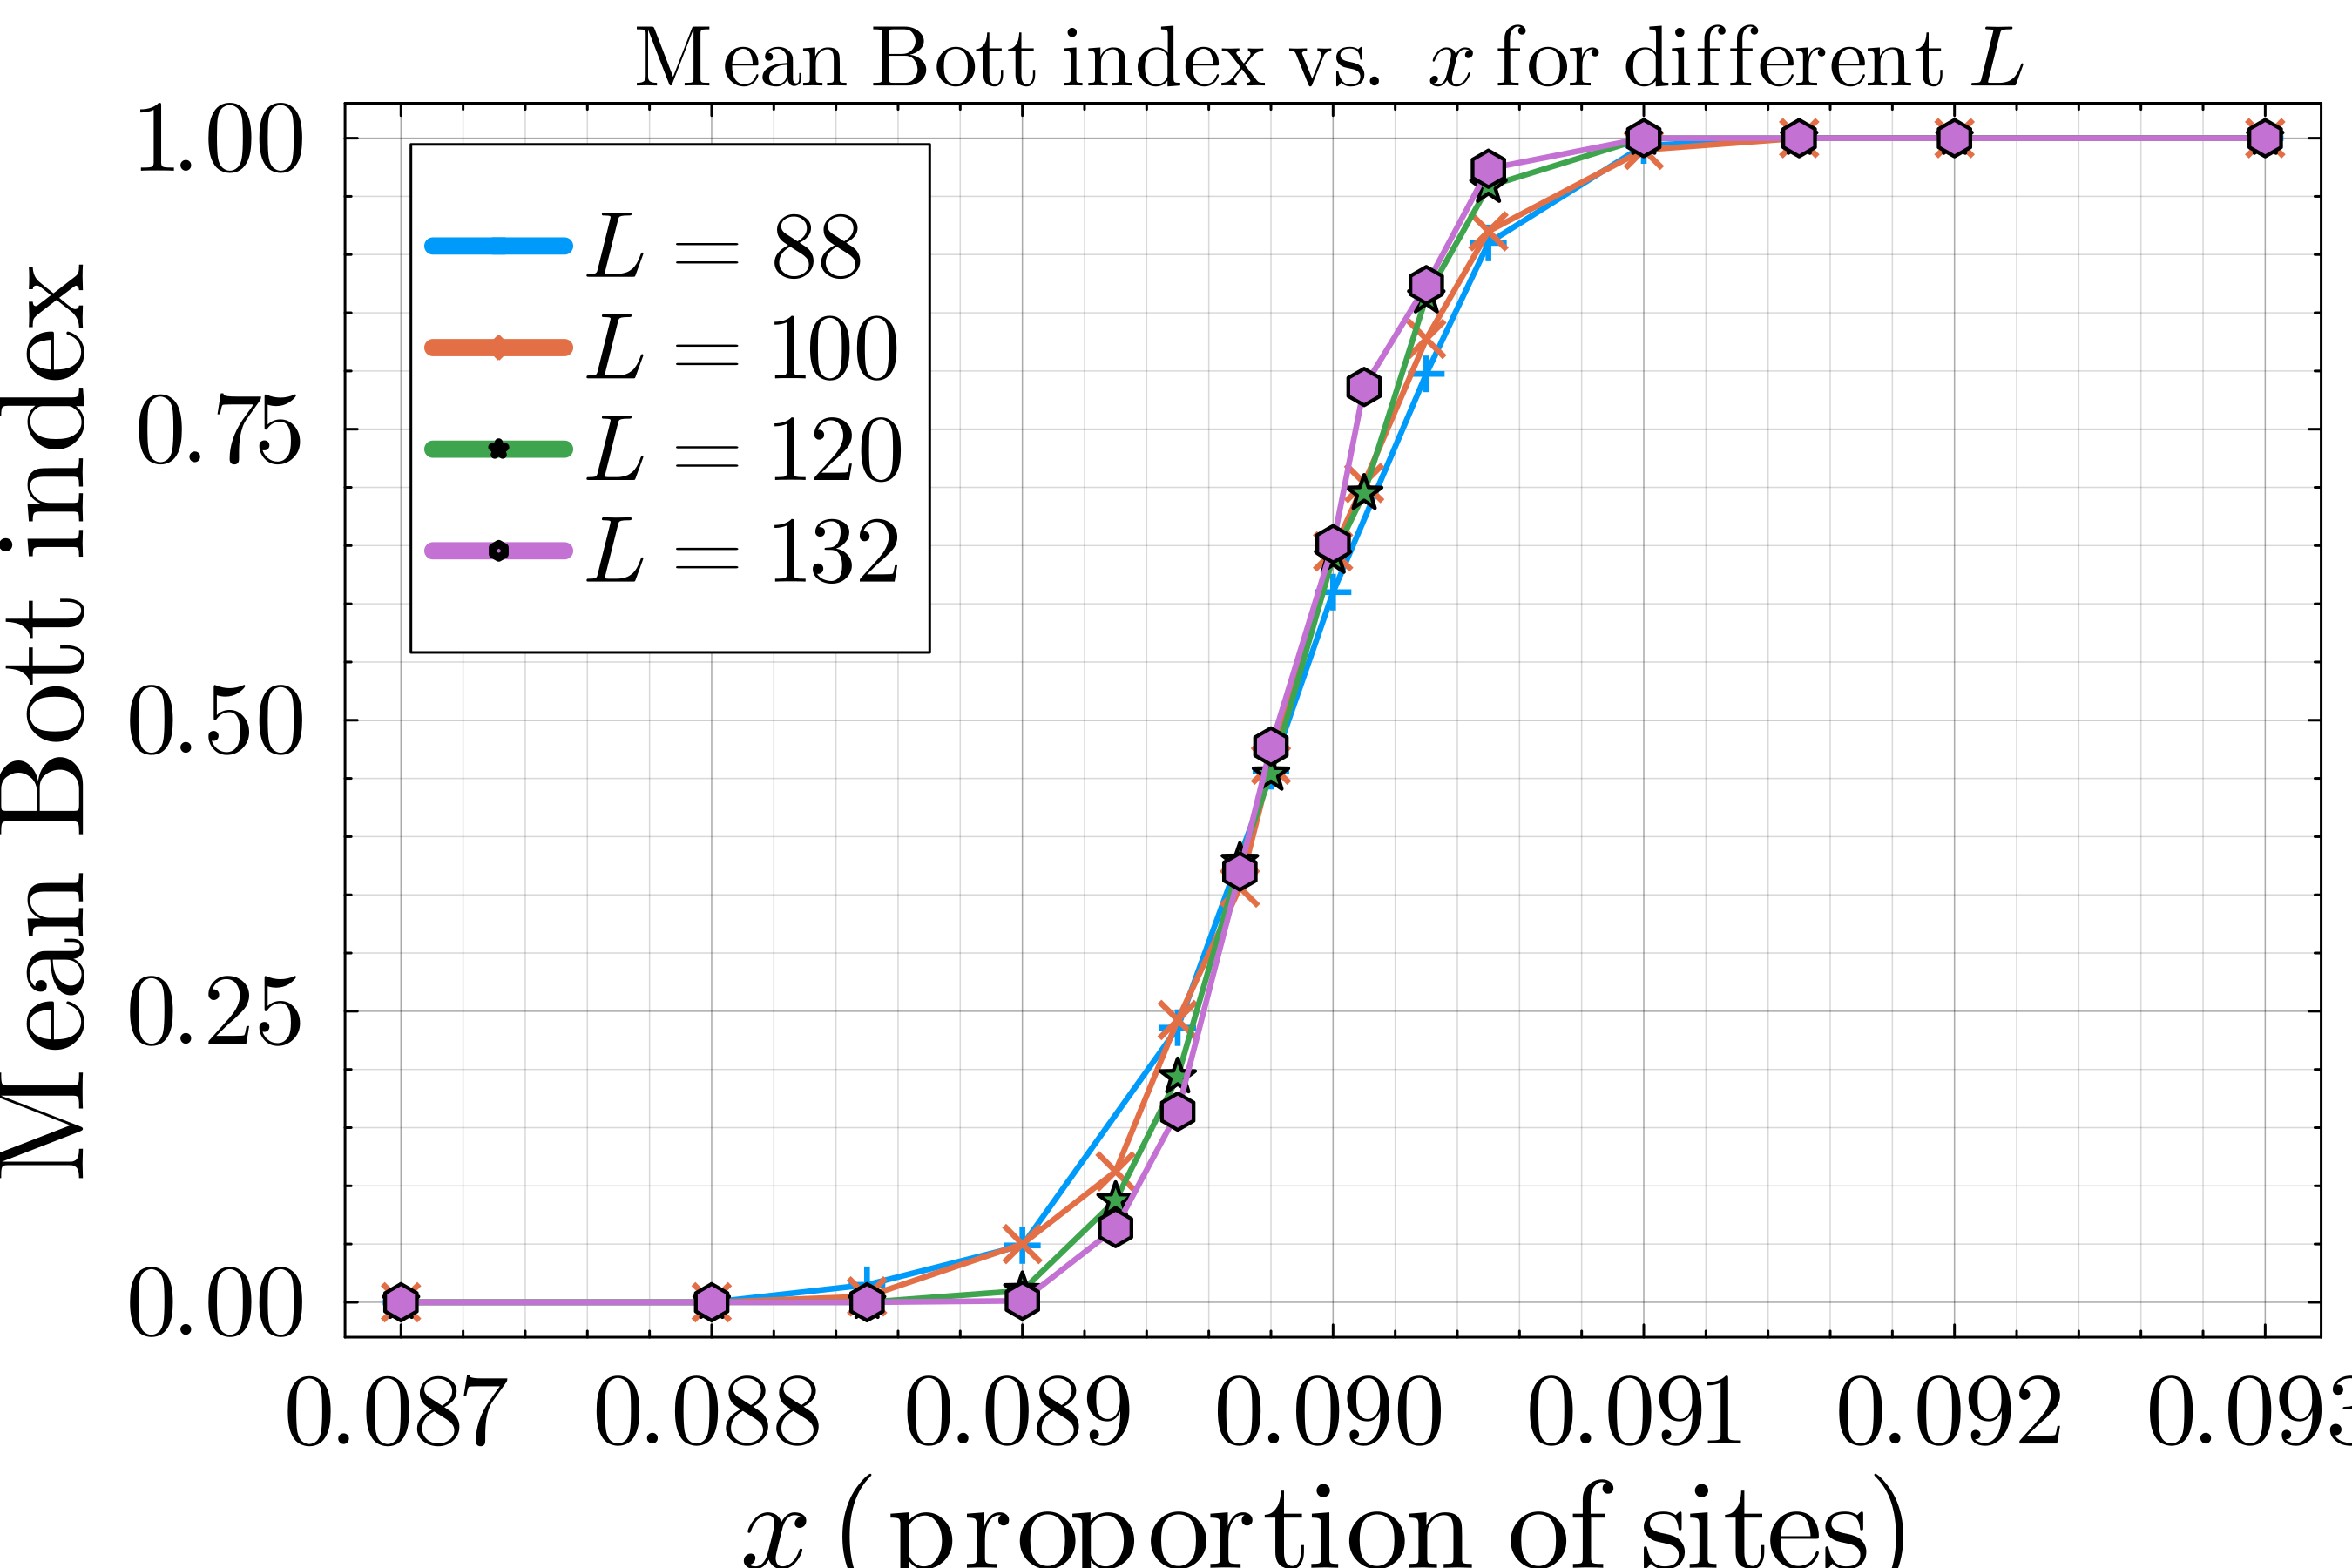

In [35]:
# p = plot(x60, y60; label="L=60", marker=:circle, markersize=6)
p = plot(x88, y88; label=L"L=88", marker=:cross, grid=:both, minorgrid=true, titlefontsize=22)
p = plot!(x100, y100; label=L"L=100", marker=:xcross, grid=:both, minorgrid=true, titlefontsize=22)
p = plot!(x120, y120; label=L"L=120", marker=:star)
p = plot!(x132, y132; label=L"L=132", marker=:hexagon)

p = xlabel!(L"x\; (\mathrm{proportion\ of\ sites})")
p = ylabel!(L"\mathrm{Mean\ Bott\ index}")
p = title!(L"\mathrm{Mean\ Bott\ index\ vs.}\ x\;\mathrm{for\ different}\ L")
savefig(p, plot_pdf_path("mean_bott_index_vs_x"))
p


## Finding the best-fit (nu, x_c) via data collapse quality

A good choice of `nu` and `x_c` should make the L=88/100/120/132 curves collapse onto a single universal curve after rescaling. The problem: rescaling `(x .- x_c) .* L^(1/nu)` moves each L-series to *different* x-positions, so you can't compare `y88, y100, ...` index-by-index — a plain `std` across them is comparing unrelated x values.

The fix used below:
1. Rescale each curve's x-axis for the given `(nu, x_c)`.
2. Interpolate all curves onto a shared grid, restricted to the x-range where *all* curves overlap.
3. At each grid point, take the standard deviation of the (interpolated) y-values across curves — this measures how far apart the curves are at that point.
4. Average that spread over the grid into one "collapse error" scalar.
5. Grid-search over `(nu, x_c)` to find the minimum — the best fit.

In [36]:
# After collapse, the x-axis values will be different due to scaling.
# To compare different L curves, we will create a common set of x axis values
# and linearly interpolate to get y axis values at them
function interp_at(xs::AbstractVector, ys::AbstractVector, xq::Real)
    tol = 8 * eps(max(abs(xs[1]), abs(xs[end]), 1.0))
    (xq < xs[1] - tol || xq > xs[end] + tol) && return NaN
    xq = clamp(xq, xs[1], xs[end])
    i = searchsortedlast(xs, xq)
    i == 0 && return ys[1]
    i == length(xs) && return ys[end]
    x0, x1 = xs[i], xs[i + 1]
    y0, y1 = ys[i], ys[i + 1]
    t = (xq - x0) / (x1 - x0)
    return y0 + t * (y1 - y0)
end


# Compute "Collapse error" for a given (nu, x_c) over this common x-axis grid
function collapse_error(nu, x_c; n_grid=200)
    datasets = [(x88, y88, 88), (x100, y100, 100), (x120, y120, 120), (x132, y132, 132)]
    isempty_curves = [L for (x, _, L) in datasets if isempty(x)]
    isempty(isempty_curves) || error("No loaded data for L=$(join(isempty_curves, ", ")); check data_dir_stats and the selected parameters")

    curves = map(datasets) do (x, y, L)
        xr = (x .- x_c) .* L^(1 / nu)
        order = sortperm(xr)
        (xr[order], y[order])
    end

    lo = maximum(xr[1] for (xr, _) in curves)
    hi = minimum(xr[end] for (xr, _) in curves)
    lo >= hi && return Inf   # rescaled curves no longer overlap at all

    grid = range(lo, hi; length=n_grid)
    spreads = [std([interp_at(xr, y, xq) for (xr, y) in curves]) for xq in grid]

    return mean(spreads)
end

collapse_error(1.5, mean(x_vals)), collapse_error(2.0, mean(x_vals)), collapse_error(2.5, mean(x_vals)), collapse_error(3.0, mean(x_vals))

(0.006408683947713103, 0.00710887419483981, 0.007624551332812078, 0.008013920765620118)

Best fit: nu = 1.27, x_c = 0.0898, collapse_error = 0.005239187970671888


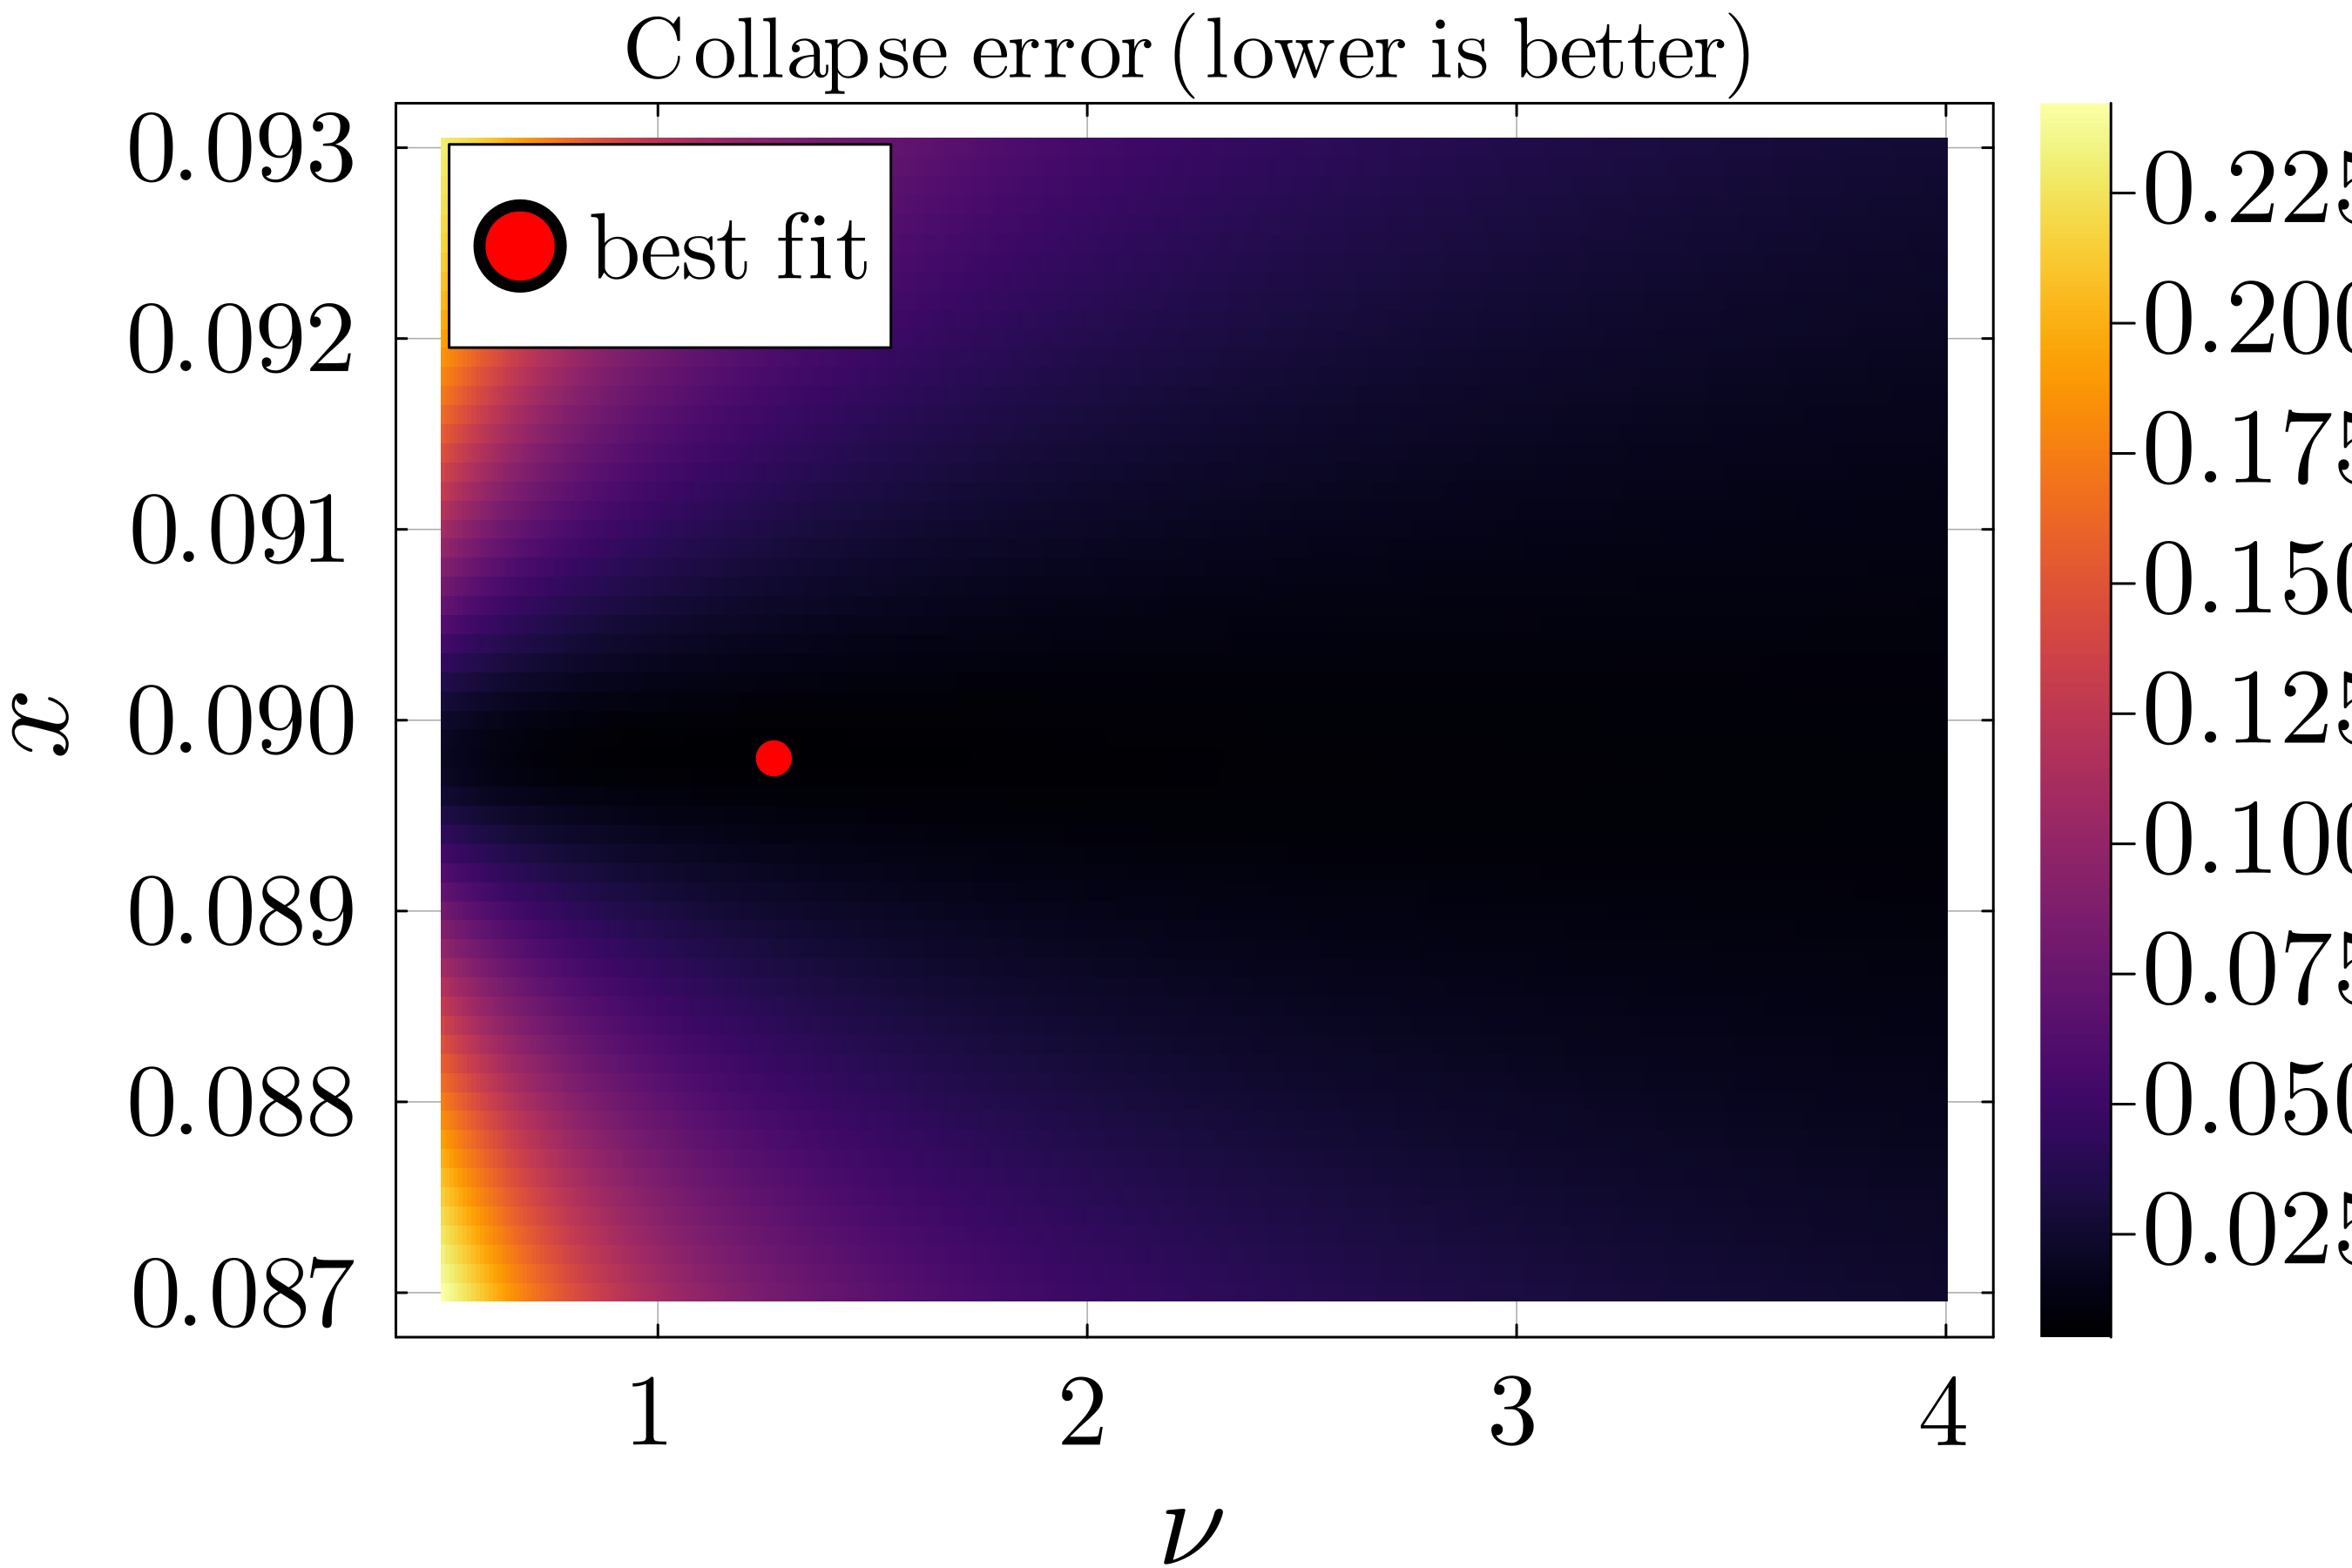

In [37]:
# Grid search over (nu, x_c) to find the best data collapse.
nu_range = 0.5:0.01:4.0
xc_range = minimum(x_vals):0.0001:maximum(x_vals)  # only search over the range of x-values we have data for

errs = [collapse_error(nu, xc) for xc in xc_range, nu in nu_range]

best_idx = argmin(replace(errs, NaN => Inf))
best_xc = xc_range[best_idx[1]]
best_nu = nu_range[best_idx[2]]
println("Best fit: nu = $best_nu, x_c = $best_xc, collapse_error = $(errs[best_idx])")

errs_plot = replace(errs, Inf => NaN)  # so the heatmap color scale isn't blown out
p_error_heatmap = heatmap(nu_range, xc_range, errs_plot;
    xlabel=L"\nu", ylabel=L"x",
    title=L"\mathrm{Collapse\ error}\; (\mathrm{lower\ is\ better})",
    colorbar_tickfontsize=32,
    titlefontsize=22,
    right_margin=10Plots.mm)
scatter!(p_error_heatmap, [best_nu], [best_xc]; markersize=9, color=:red, markerstrokewidth=2, label=L"\mathrm{best\ fit}")
savefig(p_error_heatmap, plot_pdf_path("collapse_error_heatmap"))
p_error_heatmap

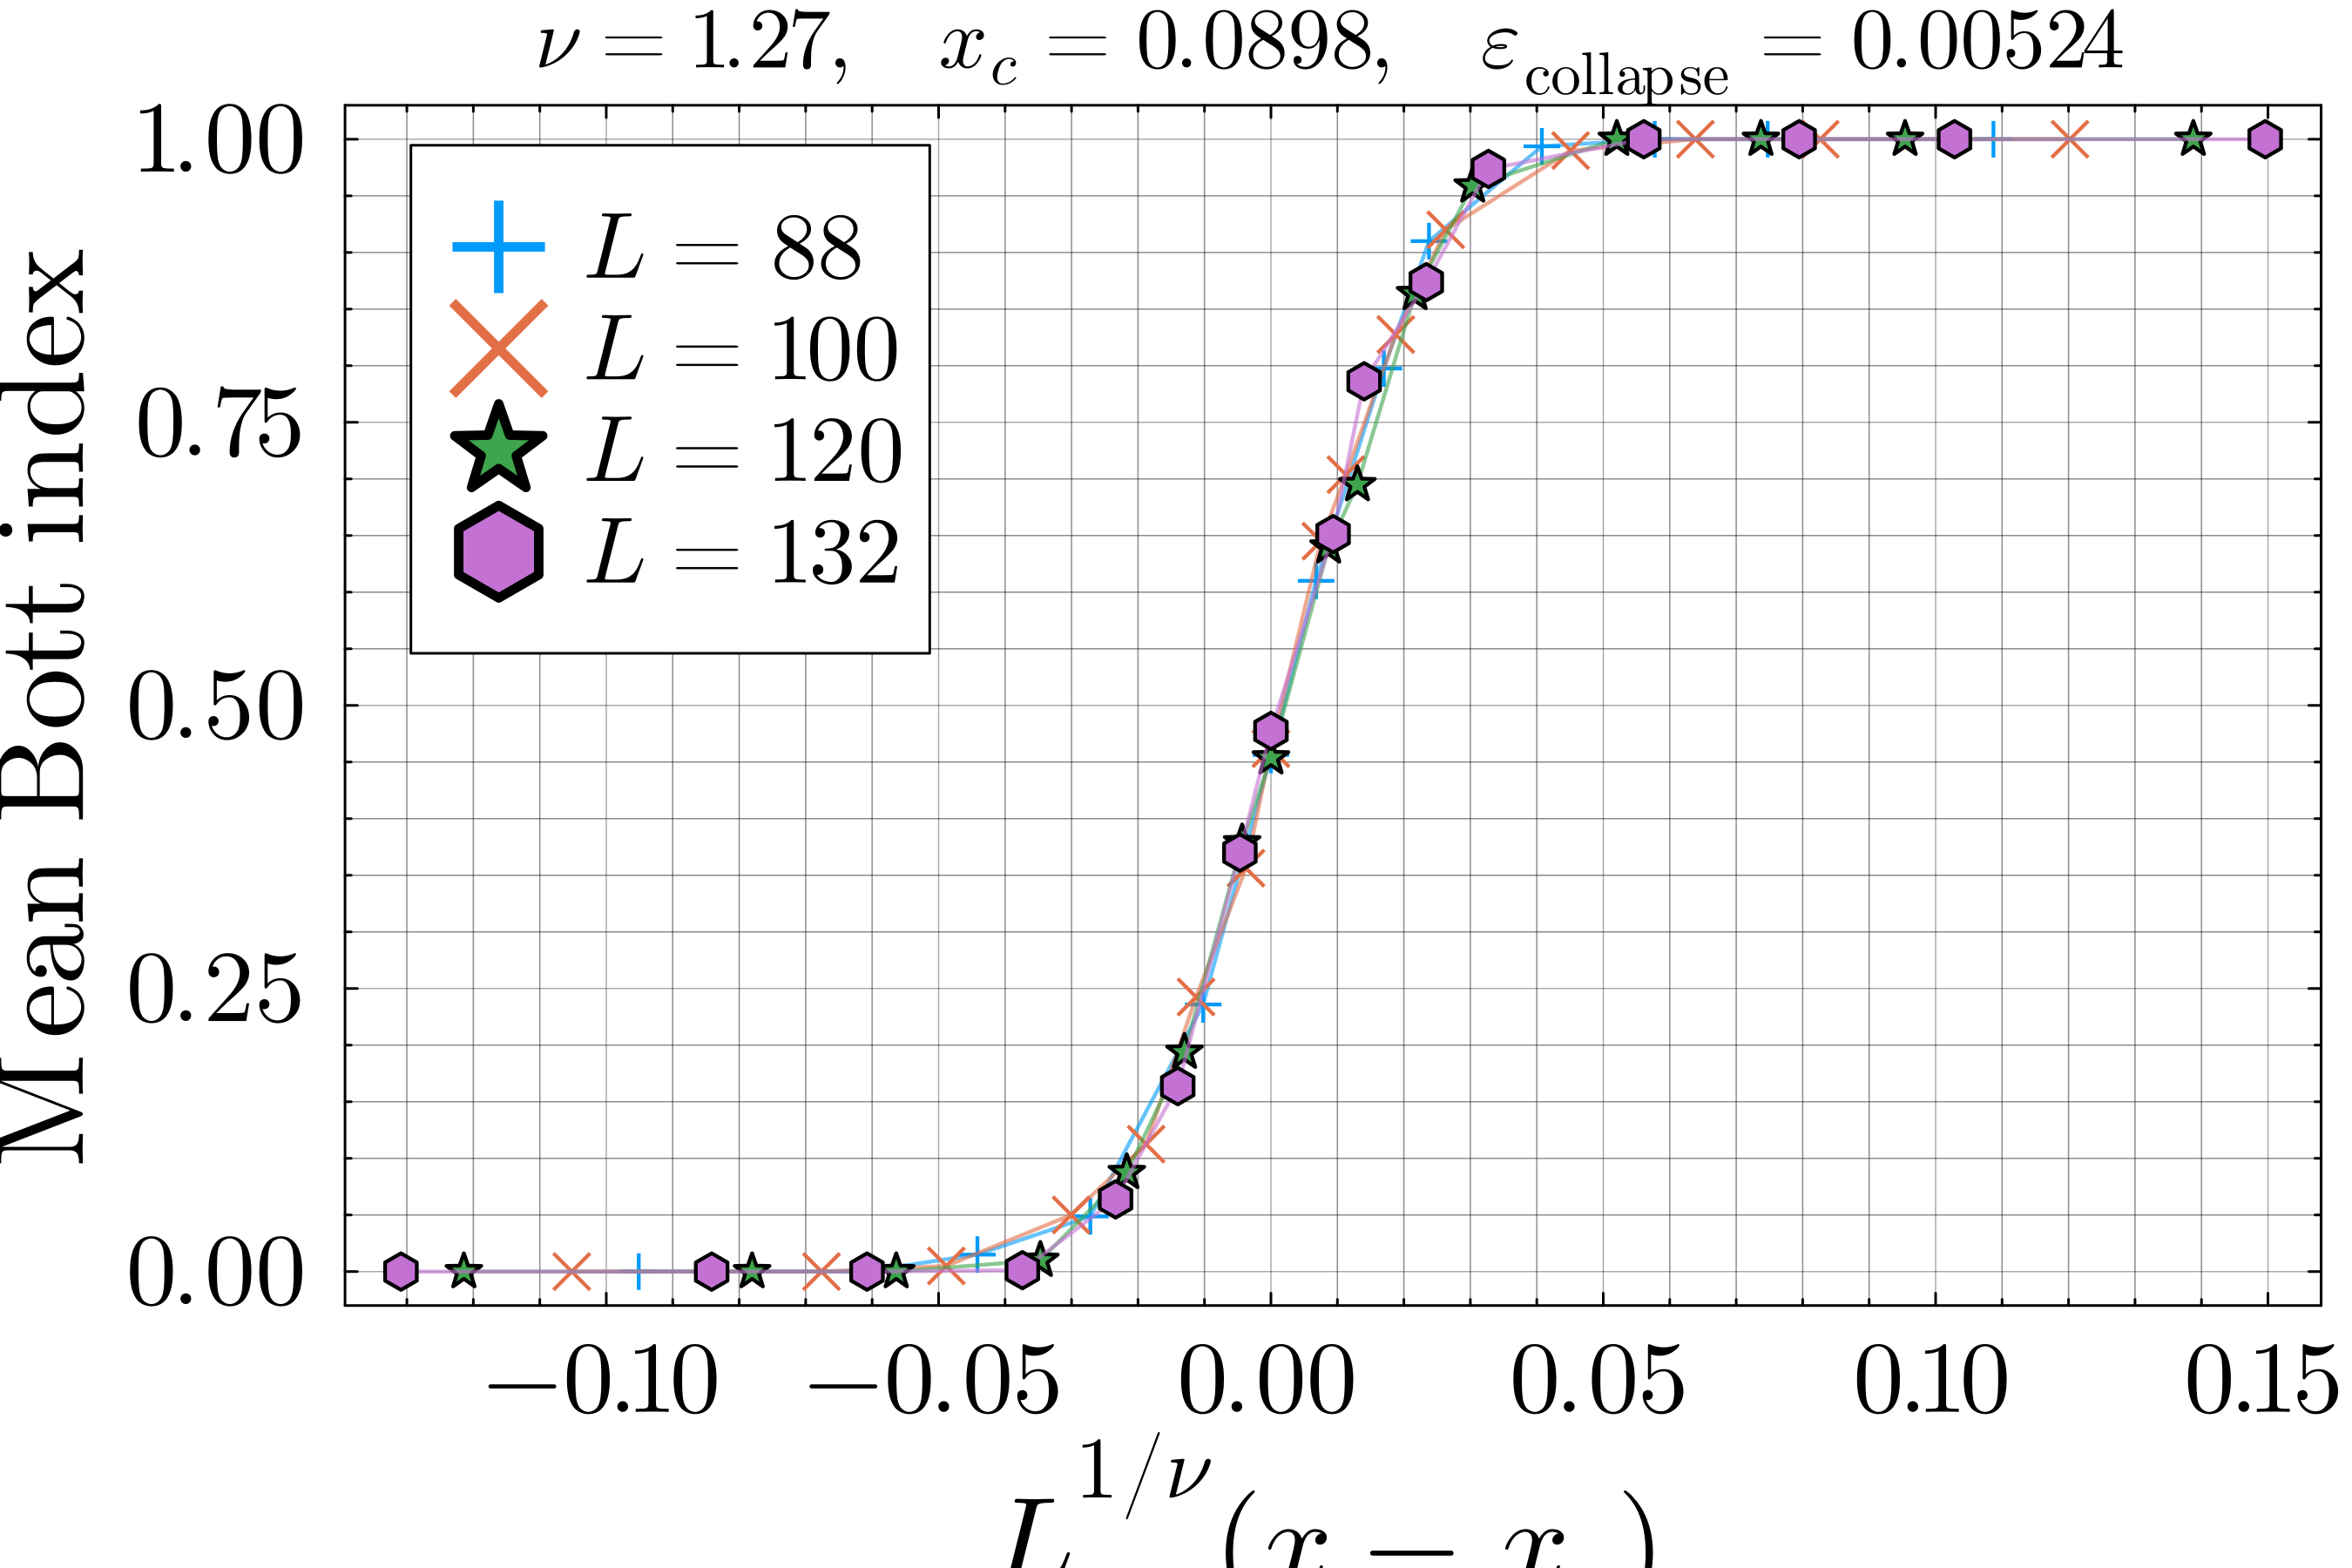

In [38]:
# Plot the data collapse at the best-fit (nu, x_c)
function plot_best_fit_collapse(nu, x_c; n_line=400)
    datasets = [
        (x88, y88, 88, :cross, 1),
        (x100, y100, 100, :xcross, 2),
        (x120, y120, 120, :star, 3),
        (x132, y132, 132, :hexagon, 4),
    ]

    p = plot(;
        xlabel=L"L^{1/\nu}(x-x_c)",
        ylabel=L"\mathrm{Mean\ Bott\ index}",
        title=latexstring(raw"\nu = ", nu, raw",\quad x_c = ", x_c, raw",\quad \epsilon_{\mathrm{collapse}} = ", round(collapse_error(nu, x_c), digits=5)),
        grid=:both,
        minorgrid=true,
        minorgridalpha=0.25,
        minorgridlinewidth=0.5,
        legend=:topleft,
        titlefontsize=22,
    )

    for (x, y, L, marker, color) in datasets
        xr = (x .- x_c) .* L^(1 / nu)
        order = sortperm(xr)
        xr, y = xr[order], y[order]

        line_x = range(xr[1], xr[end]; length=n_line)
        line_y = [interp_at(xr, y, xq) for xq in line_x]

        plot!(p, line_x, line_y; label="", color=color, linewidth=1.5, alpha=0.6)
        scatter!(p, xr, y; label=latexstring("L = ", L), marker=marker, markersize=7, color=color)
    end

    return p
end

p_best_fit_collapse = plot_best_fit_collapse(best_nu, best_xc)
savefig(p_best_fit_collapse, plot_pdf_path("best_fit_collapse"))
p_best_fit_collapse

## Publication-quality versions of `p` and `p_best_fit_collapse` (Python / matplotlib)

Saved: /home/archisman/data plots/chern_BHZ/bott_index/mean_bott_index_vs_x_m_0=-1.75.pdf


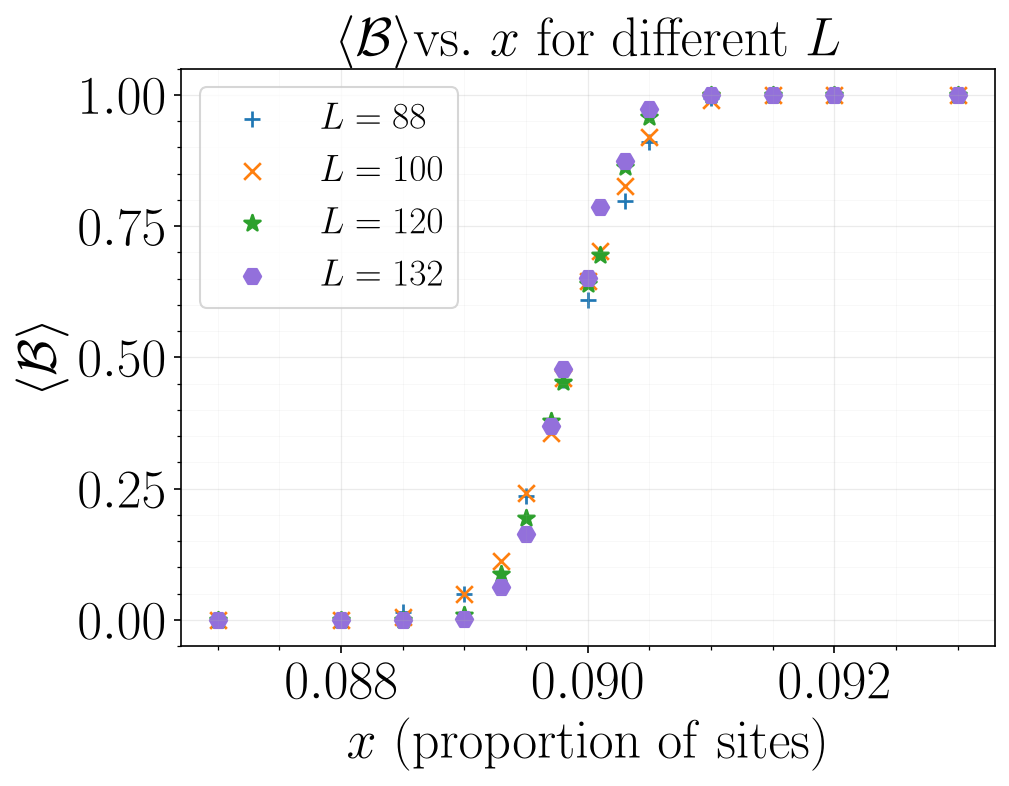

In [39]:
let
    png_path = tempname() * ".png"

    code = raw"""
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    import numpy as np

    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "axes.labelsize": 26,
        "axes.titlesize": 26,
        "xtick.labelsize": 26,
        "ytick.labelsize": 26,
        "legend.fontsize": 18,
    })

    datasets = [
        (np.asarray(x88),  np.asarray(y88),  88,  "+", "C0"),
        (np.asarray(x100), np.asarray(y100), 100, "x", "C1"),
        (np.asarray(x120), np.asarray(y120), 120, "*", "C2"),
        (np.asarray(x132), np.asarray(y132), 132, "H", "mediumpurple"),
    ]

    fig, ax = plt.subplots(figsize=(7, 5), dpi=300)
    for xx, yy, L, marker, color in datasets:
        ax.scatter(xx, yy, marker=marker, s=64, linewidths=1.3,
                    color=color, label=rf"$L={L}$")

    ax.set_xlabel(r"$x\ (\mathrm{proportion\ of\ sites})$")
    ax.set_ylabel(r"$\langle \mathcal{B} \rangle$")
    ax.set_title(r"$\langle \mathcal{B} \rangle \mathrm{vs.}\ x\ \mathrm{for\ different}\ L$")
    ax.grid(True, which="major", alpha=0.25, linewidth=0.6)
    ax.minorticks_on()
    ax.grid(True, which="minor", alpha=0.1, linewidth=0.4)
    ax.legend(loc="best", frameon=True)
    fig.savefig(out_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print("Saved:", out_path)
    """
    pyexec(code, Main, (
        x88=x88, y88=y88, x100=x100, y100=y100,
        x120=x120, y120=y120, x132=x132, y132=y132,
        out_path=plot_pdf_path("mean_bott_index_vs_x"),
        png_path=png_path,
    ))

    display(MIME("image/png"), read(png_path))
    rm(png_path)
end

Saved: /home/archisman/data plots/chern_BHZ/bott_index/best_fit_collapse_m_0=-1.75.pdf


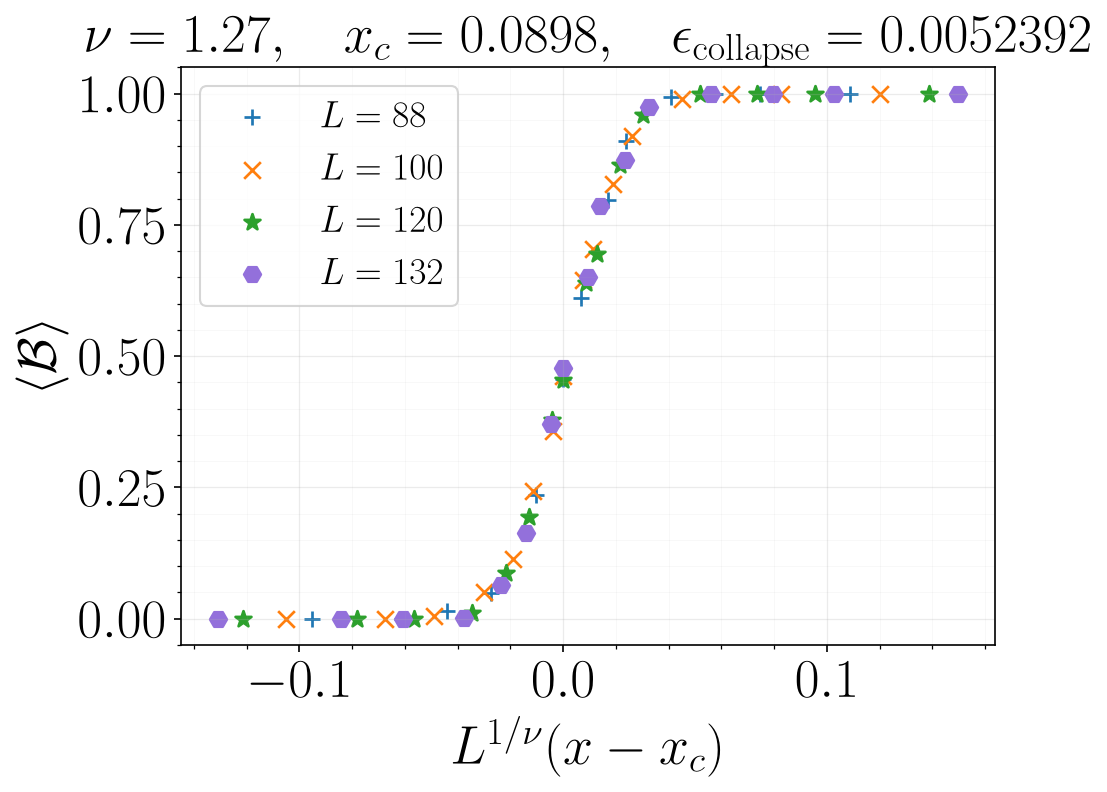

In [40]:
## Here we invoke python's matplotlib to generate a beautiful publication quality plot
let
    eps_collapse = collapse_error(best_nu, best_xc)

    xr88  = (x88  .- best_xc) .* 88^(1 / best_nu)
    xr100 = (x100 .- best_xc) .* 100^(1 / best_nu)
    xr120 = (x120 .- best_xc) .* 120^(1 / best_nu)
    xr132 = (x132 .- best_xc) .* 132^(1 / best_nu)
    png_path = tempname() * ".png"

    code = raw"""
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    import numpy as np

    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "axes.labelsize": 26,
        "axes.titlesize": 26,
        "xtick.labelsize": 26,
        "ytick.labelsize": 26,
        "legend.fontsize": 18,
    })

    datasets = [
        (np.asarray(xr88),  np.asarray(y88),  88,  "+", "C0"),
        (np.asarray(xr100), np.asarray(y100), 100, "x", "C1"),
        (np.asarray(xr120), np.asarray(y120), 120, "*", "C2"),
        (np.asarray(xr132), np.asarray(y132), 132, "H", "mediumpurple"),
    ]

    fig, ax = plt.subplots(figsize=(7, 5), dpi=300)
    for xx, yy, L, marker, color in datasets:
        ax.scatter(xx, yy, marker=marker, s=64, linewidths=1.3,
                    color=color, label=rf"$L={L}$")

    ax.set_xlabel(r"$L^{1/\nu}(x-x_c)$")
    ax.set_ylabel(r"$\langle \mathcal{B} \rangle$")
    ax.set_title(rf"$\nu = {nu:.4g},\quad x_c = {xc:.4g},\quad \epsilon_{{\mathrm{{collapse}}}} = {eps:.5g}$")
    ax.grid(True, which="major", alpha=0.25, linewidth=0.6)
    ax.minorticks_on()
    ax.grid(True, which="minor", alpha=0.1, linewidth=0.4)
    ax.legend(loc="best", frameon=True)
    fig.savefig(out_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print("Saved:", out_path)
    """
    pyexec(code, Main, (
        xr88=xr88, y88=y88, xr100=xr100, y100=y100,
        xr120=xr120, y120=y120, xr132=xr132, y132=y132,
        nu=best_nu, xc=best_xc, eps=eps_collapse,
        out_path=plot_pdf_path("best_fit_collapse"),
        png_path=png_path,
    ))

    display(MIME("image/png"), read(png_path))
    rm(png_path)
end

## Bootstrap standard error of the scaling exponent

In [41]:
using Random

function load_bott_bootstrap_data(series, m0; data_dir=data_dir_stats, n_max=typemax(Int))
    n_max > 0 || error("n_max must be positive")
    wanted = [(L, Float64(x)) for (xs, L) in series for x in xs]
    length(unique(wanted)) == length(wanted) || error("Duplicate (L, x) points")
    files = Dict(key => Tuple{DateTime,String}[] for key in wanted)

    # Match the original loader's tolerance, timestamp ordering, and n_max cap.
    for f in readdir(data_dir)
        endswith(f, ".csv") || continue
        params = _parse_bott_filename(f)
        params === nothing && continue
        isapprox(params.m_0, m0; atol=1e-12, rtol=0) || continue
        k = findfirst(wanted) do (L, x)
            L == params.L &&
                isapprox(x, params.proportion_sites; atol=1e-12, rtol=0)
        end
        k === nothing && continue
        push!(files[wanted[k]], (params.timestamp, f))
    end

    return map(series) do (xs, L)
        length(xs) >= 2 || error("Need at least two x points for L=$L")
        order = sortperm(xs)
        x = Float64.(xs[order])
        all(diff(x) .> 0) || error("Repeated x points for L=$L")

        samples = map(x) do xi
            matches = sort(files[(L, xi)]; by=first)
            isempty(matches) && error("No matching CSVs for L=$L, x=$xi, m_0=$m0")
            values = Float64[]
            for (_, f) in Iterators.take(matches, n_max)
                df = CSV.read(joinpath(data_dir, f), DataFrame; silencewarnings=true)
                hasproperty(df, :bott_index) || continue
                vals = collect(skipmissing(df.bott_index))
                isempty(vals) && continue
                push!(values, round(Int, vals[end]))
            end
            length(values) >= 2 || error("Need at least two valid runs for L=$L, x=$xi")
            values
        end

        (; x, L, samples)
    end
end;

In [42]:
bootstrap_data = load_bott_bootstrap_data(
    [(x88, 88), (x100, 100), (x120, 120), (x132, 132)],
    target; n_max=max_num_to_try,
);

In [43]:
function bootstrap_collapse_error(nu, xc, datasets; n_grid=200)
    isfinite(nu) && nu > 0 && isfinite(xc) || return Inf
    n_grid >= 2 || error("n_grid must be at least 2")
    length(datasets) >= 2 || error("Need at least two system sizes")
    curves = [((x .- xc) .* L^(1 / nu), y) for (x, y, L) in datasets]
    lo = maximum(first(xr) for (xr, _) in curves)
    hi = minimum(last(xr) for (xr, _) in curves)
    isfinite(lo) && isfinite(hi) && lo < hi || return Inf

    total = 0.0
    for xq in range(lo, hi; length=n_grid)
        avg, m2 = 0.0, 0.0
        for (k, (xr, y)) in enumerate(curves)
            v = interp_at(xr, y, xq)
            isfinite(v) || return Inf
            delta = v - avg
            avg += delta / k
            m2 += delta * (v - avg)
        end
        total += sqrt(max(m2, 0.0) / (length(curves) - 1))
    end
    return total / n_grid
end

function bootstrap_grid_fit(datasets, nus, xcs; n_grid=200)
    isempty(nus) && error("Empty nu grid")
    isempty(xcs) && error("Empty x_c grid")
    all(isfinite, nus) && all(nus .> 0) ||
        error("nu grid must be finite and positive")
    all(isfinite, xcs) || error("x_c grid must be finite")
    issorted(nus) && issorted(xcs) || error("Parameter grids must be sorted")
    for (x, y, L) in datasets
        length(x) == length(y) && length(x) >= 2 || error("Invalid curve for L=$L")
        all(isfinite, x) && all(isfinite, y) && all(diff(x) .> 0) ||
            error("Curves must have finite values and strictly increasing x")
        isfinite(L) && L > 0 || error("System sizes must be positive")
    end

    best_loss, best_nu = Inf, NaN
    for nu in nus, xc in xcs
        loss = bootstrap_collapse_error(nu, xc, datasets; n_grid=n_grid)
        if loss < best_loss
            best_loss, best_nu = loss, nu
        end
    end
    isfinite(best_nu) || error("No finite collapse fit on this grid; check curve overlap")
    return best_nu
end

function bootstrap_nu_standard_error(data, nus, xcs; repetitions=300, seed=2026, n_grid=200)
    repetitions >= 2 || error("Need at least two bootstrap repetitions")
    all(length(v) >= 2 for d in data for v in d.samples) ||
        error("Each point needs at least two runs")
    rng = MersenneTwister(seed)
    nu_draws = Vector{Float64}(undef, repetitions)
    boot_curves = [(d.x, zeros(length(d.x)), d.L) for d in data]
    for b in 1:repetitions
        for (i, d) in enumerate(data), j in eachindex(d.samples)
            values = d.samples[j]
            # Draw length(values) raw values with replacement, then take the mean.
            boot_curves[i][2][j] =
                sum(rand(rng, values) for _ in eachindex(values)) / length(values)
        end
        nu_draws[b] = bootstrap_grid_fit(boot_curves, nus, xcs; n_grid=n_grid)
        if b % 10 == 0 || b == repetitions
            println("Bootstrap: $b / $repetitions")
        end
    end
    return std(nu_draws)
end

bootstrap_nu_standard_error (generic function with 1 method)

In [44]:
bootstrap_repetitions = 1000
bootstrap_seed = 2026
bootstrap_n_grid = 200

nu_standard_error = bootstrap_nu_standard_error(
    bootstrap_data, nu_range, xc_range;
    repetitions=bootstrap_repetitions,
    seed=bootstrap_seed,
    n_grid=bootstrap_n_grid,
)
println("Bootstrap standard error of nu: $nu_standard_error")

Bootstrap: 10 / 1000
Bootstrap: 20 / 1000
Bootstrap: 30 / 1000
Bootstrap: 40 / 1000
Bootstrap: 50 / 1000
Bootstrap: 60 / 1000
Bootstrap: 70 / 1000
Bootstrap: 80 / 1000
Bootstrap: 90 / 1000
Bootstrap: 100 / 1000
Bootstrap: 110 / 1000
Bootstrap: 120 / 1000
Bootstrap: 130 / 1000
Bootstrap: 140 / 1000
Bootstrap: 150 / 1000
Bootstrap: 160 / 1000
Bootstrap: 170 / 1000
Bootstrap: 180 / 1000
Bootstrap: 190 / 1000
Bootstrap: 200 / 1000
Bootstrap: 210 / 1000
Bootstrap: 220 / 1000
Bootstrap: 230 / 1000
Bootstrap: 240 / 1000
Bootstrap: 250 / 1000
Bootstrap: 260 / 1000
Bootstrap: 270 / 1000
Bootstrap: 280 / 1000
Bootstrap: 290 / 1000
Bootstrap: 300 / 1000
Bootstrap: 310 / 1000
Bootstrap: 320 / 1000
Bootstrap: 330 / 1000
Bootstrap: 340 / 1000
Bootstrap: 350 / 1000
Bootstrap: 360 / 1000
Bootstrap: 370 / 1000
Bootstrap: 380 / 1000
Bootstrap: 390 / 1000
Bootstrap: 400 / 1000
Bootstrap: 410 / 1000
Bootstrap: 420 / 1000
Bootstrap: 430 / 1000
Bootstrap: 440 / 1000
Bootstrap: 450 / 1000
Bootstrap: 460 / 10

In [ ]:
half_interval_size = 1.96 * nu_standard_error

0.25551324567966677